# Compile `[res, k_views, mean, median, p90]` from chunked CSV
This notebook cell parses the chunked CSV format:
- Header line contains `_res_<n>_k_views_<m>`
- Followed by `Mean`, `Median`, `P90` blocks
- For each block, we take the bottom-right entry: row `all` and column `all` (the last column in that row).

In [1]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Optional, List, Dict, Tuple

import pandas as pd


HEADER_RE = re.compile(r"(?:^|_)res_(?P<res>\d+)_k_views_(?P<k_views>\d+)(?:$|\b|_)")


class ParseError(RuntimeError):
    pass


def _is_metric_label(line: str) -> bool:
    return line.strip() in {"Mean", "Median", "P90"}


def _looks_like_chunk_header(line: str) -> bool:
    line = line.strip()
    if not line:
        return False
    if _is_metric_label(line):
        return False
    if line.startswith("Problem Group"):
        return False
    return HEADER_RE.search(line) is not None


def _parse_chunk_header(line: str) -> Tuple[int, int]:
    m = HEADER_RE.search(line)
    if not m:
        raise ParseError(f"Could not find '_res_<n>_k_views_<n>' in header line: {line!r}")
    return int(m.group("res")), int(m.group("k_views"))


def _parse_metric_all_all(lines: List[str], start_idx: int, metric_name: str) -> Tuple[float, int]:
    """Parse one metric table starting at start_idx (line after metric label)."""
    i = start_idx
    while i < len(lines) and not lines[i].strip():
        i += 1
    if i >= len(lines) or not lines[i].lstrip().startswith("Problem Group"):
        got = lines[i].rstrip() if i < len(lines) else "<EOF>"
        raise ParseError(f"Expected 'Problem Group,...' header after {metric_name}, got: {got}")

    all_row: Optional[List[str]] = None
    i += 1  # skip table header
    while i < len(lines):
        raw = lines[i].rstrip("\n")
        stripped = raw.strip()
        if not stripped:
            break
        if _is_metric_label(stripped) or _looks_like_chunk_header(stripped):
            break
        # Parse as CSV row (handles commas safely)
        row = next(pd.read_csv(pd.io.common.StringIO(raw), header=None).itertuples(index=False, name=None))
        row = ["" if pd.isna(x) else str(x) for x in row]
        if row and str(row[0]).strip().lower() == "all":
            all_row = row
        i += 1

    if all_row is None:
        raise ParseError(f"Did not find 'all' row in {metric_name} table")
    value_str = str(all_row[-1]).strip()
    try:
        value = float(value_str)
    except ValueError as e:
        raise ParseError(f"Could not parse all/all value {value_str!r} in {metric_name}") from e
    return value, i


def compile_chunked_metrics_table(csv_path: str | Path) -> pd.DataFrame:
    """Return DataFrame with columns: res,k_views,mean,median,p90."""
    csv_path = Path(csv_path)
    text = csv_path.read_text(encoding="utf-8", errors="replace")
    lines = text.splitlines()

    rows: List[Dict[str, float]] = []
    i = 0
    while i < len(lines):
        while i < len(lines) and not lines[i].strip():
            i += 1
        if i >= len(lines):
            break

        line = lines[i]
        if not _looks_like_chunk_header(line):
            i += 1
            continue

        res, k_views = _parse_chunk_header(line)
        i += 1

        def expect(label: str) -> None:
            nonlocal i
            while i < len(lines) and not lines[i].strip():
                i += 1
            got = lines[i].strip() if i < len(lines) else "<EOF>"
            if got != label:
                raise ParseError(f"Expected {label!r}, got {got!r} (res={res}, k_views={k_views})")
            i += 1

        expect("Mean")
        mean, i = _parse_metric_all_all(lines, i, "Mean")
        expect("Median")
        median, i = _parse_metric_all_all(lines, i, "Median")
        expect("P90")
        p90, i = _parse_metric_all_all(lines, i, "P90")

        rows.append({"res": res, "k_views": k_views, "mean": mean, "median": median, "p90": p90})

        while i < len(lines) and not lines[i].strip():
            i += 1

    if not rows:
        raise ParseError("No chunks parsed. Check the header format '_res_<n>_k_views_<n>' and Mean/Median/P90 blocks.")

    df = pd.DataFrame(rows).sort_values(["res", "k_views"]).reset_index(drop=True)
    return df

In [2]:
# Point this to whichever file you want to parse
protocol = 'LPO'
csv_path = Path(f"AS_mean_median_p90__{protocol}__ALL_RUNS.csv")

df_compiled = compile_chunked_metrics_table(csv_path)
df_compiled['budget'] = df_compiled['res'] ** 2 * df_compiled['k_views']
df_compiled

,res,k_views,mean,median,p90,budget
0,8,1,92.030375,1.821,12.051,64
1,8,2,194.314125,1.639,12.051,128
2,8,4,25.398875,1.607,8.897,256
3,8,8,184.953542,1.597,7.241,512
4,8,16,224.712375,1.727,7.561,1024
5,8,32,233.888125,1.672,7.241,2048
6,8,64,247.499625,1.767,9.531,4096
7,8,128,699.776625,1.672,14.863,8192
8,16,1,96.751458,1.788,10.090,256
9,16,2,146.040625,1.639,7.758,512


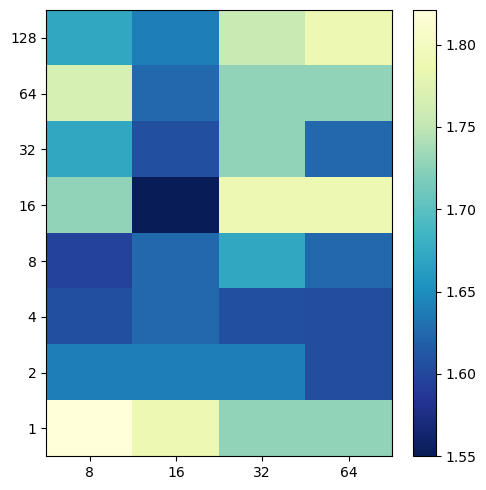

In [3]:
# Heatmap of performance over res and k_views with correct axis labels
import matplotlib.pyplot as plt
import numpy as np

pivot = df_compiled.pivot_table(index="k_views", columns="res", values="median", aggfunc="mean")
pivot = pivot.sort_index().sort_index(axis=1)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(pivot.values, aspect="auto", origin="lower", cmap='YlGnBu_r')

# Use actual res/k_views values as tick labels (imshow defaults to 0..N-1 otherwise)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns.astype(int))
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index.astype(int), ha="right")

# ax.set_title("Median heatmap over res × k_views")
# ax.set_xlabel("Number of plots")
# ax.set_ylabel("Resolution")
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.savefig(f"{protocol}_median_heatmap.svg")
plt.show()

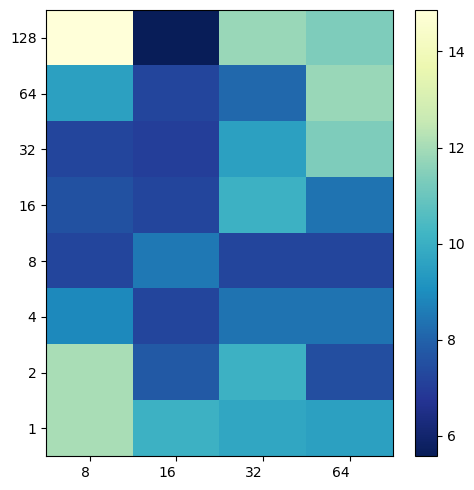

In [4]:
# Heatmap of performance over res and k_views with correct axis labels
import matplotlib.pyplot as plt
import numpy as np

pivot = df_compiled.pivot_table(index="k_views", columns="res", values="p90", aggfunc="mean")
pivot = pivot.sort_index().sort_index(axis=1)

fig, ax = plt.subplots(figsize=(5, 5))
# Log-scale the values
im = ax.imshow(pivot.values, aspect="auto", origin="lower", cmap='YlGnBu_r')

# Use actual res/k_views values as tick labels (imshow defaults to 0..N-1 otherwise)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns.astype(int), ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index.astype(int))

# ax.set_title("p90 heatmap over res × k_views")
# ax.set_xlabel("Number of plots")
# ax.set_ylabel("Resolution")
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.savefig(f"{protocol}_p90_heatmap.svg")
plt.show()